In [6]:
from scipy.stats import binomtest
from statsmodels.stats.multitest import multipletests
import numpy as np

def select_candidates(uids, fractions, n_models, alpha=0.05):
    """
    Description:
        Run BH-FDR-corrected one-sided binomial test against the median
        baseline, returning significant uids and the lowest passing fraction.

    Args:
        uids: List of identifiers, one per entry.
        fractions: List of observed proportions (e.g. NAC fractions).
        n_models: List of sample sizes (per entry).
        alpha: FDR level.

    Returns:
        Tuple (set of significant uids, lowest significant fraction or None).
    """

    baseline = np.median(fractions)
    pvals = [binomtest(int(f * n), n, p=baseline, alternative='greater').pvalue
             for f, n in zip(fractions, n_models)]
    rejected, _, _, _ = multipletests(pvals, alpha=alpha, method='fdr_bh')
    candidates = {uids[i] for i in range(len(uids)) if rejected[i]}
    sig_fracs = [fractions[i] for i in range(len(uids)) if rejected[i]]
    threshold = min(sig_fracs) if sig_fracs else None
    return candidates, threshold


In [15]:
import pandas as pd

# suffix = '2C'
result_path = f'./results/test.csv'

df = pd.read_csv(result_path)
df_conf = df[(df['n_confident_holo'] >= 30)]

df_conf

,entry,nac_fraction_holo,nac_holo_idxs,n_confident_holo,prmsd_mean,prmsd_std
0,A0A6G9XT36.relax_A296C,0.392857,1;5;6;7;9;12;13;15;20;30;31;33;35;40;42;43;46;...,56,2.195695,1.297791
1,A0A6G9XT36.relax_A296D,0.236364,3;4;12;14;26;30;34;42;45;46;50;51;53,55,2.220743,1.316510
2,A0A6G9XT36.relax_A296E,0.098039,3;8;16;20;30,51,2.366365,1.277174
3,A0A6G9XT36.relax_A296F,0.400000,3;4;6;7;8;9;14;15;16;18;25;29;30;32;36;37;38;41,45,2.452128,1.312969
4,A0A6G9XT36.relax_A296G,0.211538,4;14;20;27;32;35;37;45;47;50;51,52,2.335563,1.297183
...,...,...,...,...,...,...
489,A0A6G9XT36.relax_Y501R,0.538462,2;4;5;6;8;9;12;17;19;20;21;22;27;29;30;31;32;3...,39,2.892136,1.437094
490,A0A6G9XT36.relax_Y501S,0.425532,4;6;9;10;13;14;15;17;26;27;28;29;31;33;37;39;4...,47,2.558937,1.274872
491,A0A6G9XT36.relax_Y501T,0.528302,1;2;4;6;8;9;10;13;15;16;18;19;20;23;25;26;27;3...,53,2.422150,1.334614
492,A0A6G9XT36.relax_Y501V,0.580000,1;2;3;4;5;8;9;10;11;15;18;20;21;26;27;29;31;32...,50,2.522248,1.344468


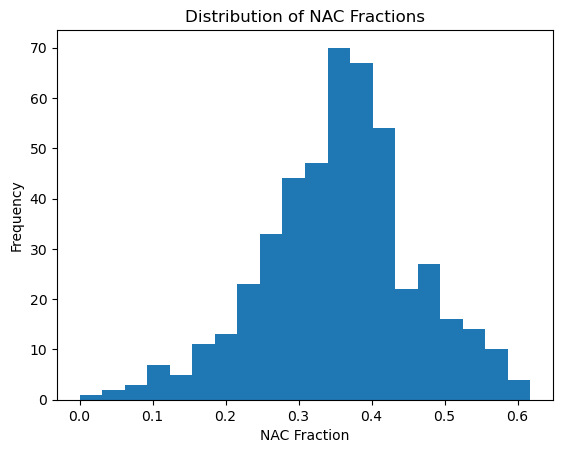

In [24]:
import matplotlib.pyplot as plt

nac_fraction = df_conf['nac_fraction_holo'].tolist()

plt.hist(nac_fraction, bins=20)
plt.xlabel('NAC Fraction')
plt.ylabel('Frequency')
plt.title('Distribution of NAC Fractions')
plt.show()


In [18]:

entries = df_conf['entry'].tolist()

nac_fraction_holo = df_conf['nac_fraction_holo'].tolist()
# nac_fraction_apo = df_conf['nac_fraction_apo'].tolist()

n_conf_models_holo = df_conf['n_confident_holo'].tolist()
# n_conf_models_apo = df_conf['n_confident_apo'].tolist()

sig_holo, thr_holo = select_candidates(entries, nac_fraction_holo, n_conf_models_holo)
# sig_apo,  thr_apo  = select_candidates(entries, nac_fraction_apo,  n_conf_models_apo)
# both = sig_holo & sig_apo

# print(f"Holo:  {len(sig_holo):>3d} / {len(entries)}  (threshold: {thr_holo:.1%})")
# print(f"Apo:   {len(sig_apo):>3d} / {len(entries)}  (threshold: {thr_apo:.1%})")
# print(f"Both:  {len(both):>3d}")

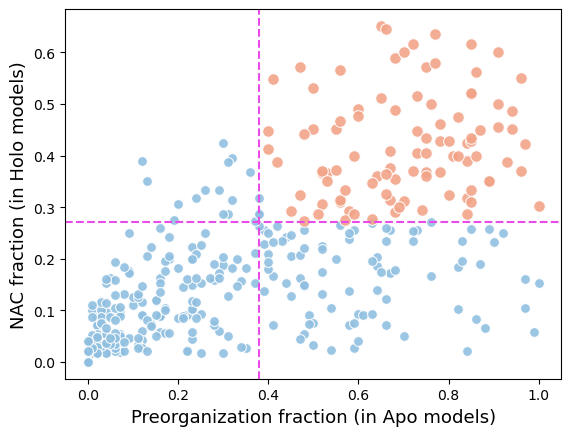

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to arrays for boolean masking
apo = np.asarray(nac_fraction_apo)
holo = np.asarray(nac_fraction_holo)

# Mask for points above both thresholds (quadrant 1)
both = (apo > thr_apo) & (holo > thr_holo)

# Base points (not in quadrant 1)
plt.scatter(apo[~both], holo[~both], s=50, c='#8fbfe0',
            edgecolors='white', linewidths=0.8, alpha=0.9)

# Highlighted points (above both thresholds)
plt.scatter(apo[both], holo[both], s=70, c='#f2a488',
            edgecolors='white', linewidths=0.8, alpha=0.9)

plt.xlabel('Preorganization fraction (in Apo models)', fontsize = 13)
plt.ylabel('NAC fraction (in Holo models)', fontsize = 13)

# Threshold lines with a softer color
plt.axhline(y=thr_holo, color="#e94be9", linestyle='--',
            label=f'Threshold: {thr_holo:.2%}')
plt.axvline(x=thr_apo, color='#e94be9', linestyle='--',
            label=f'Threshold: {thr_apo:.2%}')


plt.savefig(f'figs/nac_po_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

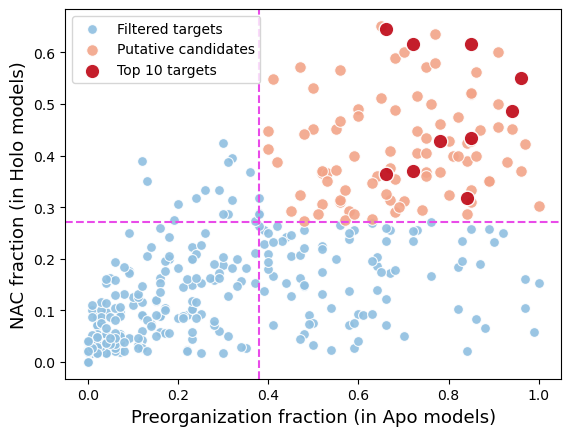

In [49]:
import numpy as np
import matplotlib.pyplot as plt


top10_ids = ['A0A0H3MCY6', 'K0EY54', 'W7J139', 'A0AAU4K3W1', 'A0A3S4RS92', 'V5XIA1', 'A0A6G9XT36', 'A0A370I008', 'A0AA37PJ36', 'E5XP76']
top10 = np.isin(np.asarray(entries), top10_ids)

# Convert to arrays for boolean masking
apo = np.asarray(nac_fraction_apo)
holo = np.asarray(nac_fraction_holo)

# Mask for points above both thresholds (quadrant 1)
both = (apo > thr_apo) & (holo > thr_holo)

# plt.scatter(apo[~top10], holo[~top10], s=50, c='#8fbfe0',
#             edgecolors='white', linewidths=0.8, alpha=0.9)
plt.scatter(apo[~both & ~top10], holo[~both & ~top10], s=50, c='#8fbfe0',
            edgecolors='white', linewidths=0.8, alpha=0.9,
            label='Filtered targets')

# Highlighted points (above both thresholds, excluding top 10)
plt.scatter(apo[both & ~top10], holo[both & ~top10], s=70, c='#f2a488',
            edgecolors='white', linewidths=0.8, alpha=0.9,
            label='Putative candidates')

# Final top 10 targets, drawn last so they sit on top
plt.scatter(apo[top10], holo[top10], s=110, c='#c1121f',
            edgecolors='white', linewidths=1.0, alpha=0.95,
            label='Top 10 targets')

plt.xlabel('Preorganization fraction (in Apo models)', fontsize = 13)
plt.ylabel('NAC fraction (in Holo models)', fontsize = 13)

# Threshold lines with a softer color
plt.axhline(y=thr_holo, color="#e94be9", linestyle='--')
plt.axvline(x=thr_apo, color='#e94be9', linestyle='--')

plt.legend(fontsize=10, loc='upper left')
plt.savefig(f'figs/nac_po_distribution_top10.png', dpi=300, bbox_inches='tight')
# plt.savefig(f'figs/test.png', dpi=300, bbox_inches='tight')
plt.show()

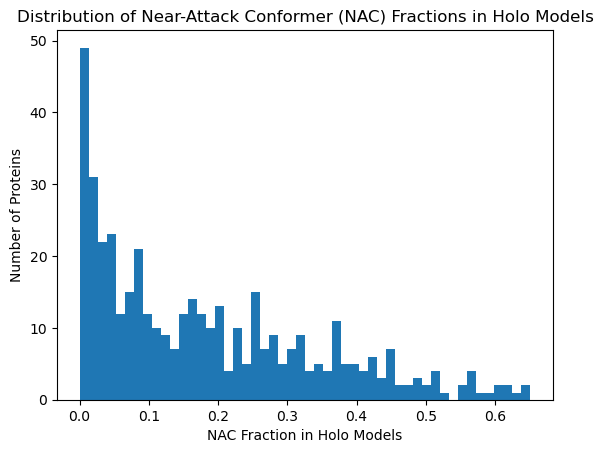

In [5]:
import matplotlib.pyplot as plt

plt.hist(nac_fraction_holo, bins=50)
plt.xlabel('NAC Fraction in Holo Models')
plt.ylabel('Number of Proteins')
plt.title('Distribution of Near-Attack Conformer (NAC) Fractions in Holo Models')
plt.show()

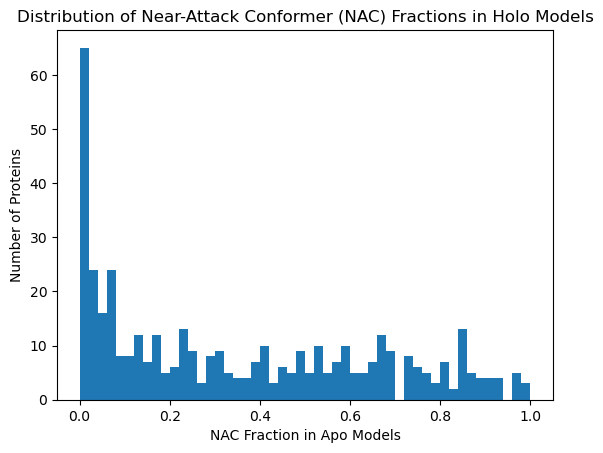

In [7]:
import matplotlib.pyplot as plt

plt.hist(nac_fraction_apo, bins=50)
plt.xlabel('NAC Fraction in Apo Models')
plt.ylabel('Number of Proteins')
plt.title('Distribution of Near-Attack Conformer (NAC) Fractions in Holo Models')
plt.show()

Split PLACER outputs into the models to satisfy NAC geometry
------------------------------------------------------------------------------

In [8]:
import os

cols = ['entry', 'nac_fraction_holo', 'nac_holo_idxs', 'n_confident_holo',
        'prmsd_mean', 'prmsd_std', 'nac_fraction_apo', 'nac_apo_idxs', 'n_confident_apo']

candidate_df = df_conf[df_conf['entry'].isin(both)].reset_index(drop=True)[cols]

candidate_df.to_csv(f'{os.path.splitext(result_path)[0]}_filtered.csv', index=False)
candidate_df

,entry,nac_fraction_holo,nac_holo_idxs,n_confident_holo,prmsd_mean,prmsd_std,nac_fraction_apo,nac_apo_idxs,n_confident_apo
0,A0A064CG00,0.588235,2;3;4;5;8;11;12;13;14;15;16;17;18;20;21;23;25;...,34,2.966543,1.320483,0.68,1;2;3;6;8;9;10;11;12;13;14;15;18;19;21;22;23;2...,100
1,A0A0F5NA60,0.404762,4;6;10;12;13;14;22;23;24;25;26;29;30;31;33;37;39,42,2.558705,1.200925,0.73,1;2;3;4;5;6;7;9;11;12;13;15;16;18;21;22;23;24;...,100
2,A0A0H3MCY6,0.428571,1;2;4;5;9;10;13;14;15;19;20;21;26;28;29;30;31;...,56,2.293562,1.297935,0.78,1;3;4;5;6;7;11;12;13;16;18;20;21;22;23;24;25;2...,100
3,A0A0I9Z3I8,0.369565,2;3;4;10;12;18;19;22;25;28;29;32;34;36;39;40;41,46,2.373432,1.138223,0.96,1;2;3;4;5;6;7;8;9;10;11;12;13;14;15;17;18;19;2...,100
4,A0A0N9YG13,0.369565,3;5;6;9;10;16;18;21;22;25;28;30;31;32;35;41;45,46,2.474927,1.046579,0.52,1;2;3;4;6;8;9;12;13;15;18;20;22;23;24;26;32;35...,100
...,...,...,...,...,...,...,...,...,...
85,A0AB73U9A3,0.300000,5;6;7;10;11;12;15;18;24;30;31;39,40,2.726113,1.238137,0.69,1;3;5;6;7;8;10;12;13;14;16;17;18;19;20;21;22;2...,100
86,E5XP76,0.615385,2;3;5;7;9;10;12;13;14;16;18;19;22;23;24;26;27;...,39,2.720116,1.225204,0.85,1;2;3;7;8;9;11;12;13;14;15;16;17;18;19;20;21;2...,100
87,K0EY54,0.485714,2;3;4;6;7;12;13;14;15;20;21;25;26;27;29;31;35,35,2.703234,1.080243,0.94,1;2;3;4;5;6;7;8;9;10;11;12;13;14;15;16;17;18;1...,100
88,V5XIA1,0.644444,1;3;4;5;6;7;9;10;11;14;16;17;18;19;21;22;23;25...,45,2.618986,1.254007,0.66,1;3;4;5;6;7;8;9;10;13;16;17;18;19;20;21;22;23;...,100


In [10]:
import os
from Bio.PDB import PDBIO
from tqdm import tqdm

from process import structure

src_dir = "outputs/placer/carA_holo_adi_amp_homologs_100_2"
dst_dir = f"inputs/docking/carA_homologs_{suffix}"
os.makedirs(dst_dir, exist_ok=True)

io = PDBIO()
for _, row in tqdm(candidate_df.iterrows(), total=len(candidate_df)):
    base_name = row['entry']
    src_path = os.path.join(src_dir, f"{base_name}.relax_model.pdb")

    out_dir = os.path.join(dst_dir, base_name)
    os.makedirs(out_dir, exist_ok=True)

    models = structure.load_models_from_pdb(src_path)
    for idx in row['nac_holo_idxs'].split(';'):
        idx = int(idx)
        io.set_structure(models[int(idx) - 1])   # 1-based -> 0-based
        io.save(os.path.join(out_dir, f"{base_name}.relax_model_{idx}.pdb"))

100%|██████████| 100/100 [02:41<00:00,  1.61s/it]


Create .sh file to run Docking simulation
------------------------------------------

In [ ]:
import os

input_dir = os.path.abspath(f"inputs/docking/carA_homologs_{suffix}")
output_dir = os.path.abspath(f"outputs/docking/carA_homologs_{suffix}")
ligand_pdbqt = os.path.abspath("inputs/rosetta/subs/adi.pdbqt")
box_path = os.path.join(input_dir, "box_coords.box.txt")
sh_path = os.path.join(input_dir, "run_vina.sh")

# Collect entries (directories) up front so we know the total for progress logging
entries = [
    e for e in sorted(os.listdir(input_dir))
    if os.path.isdir(os.path.join(input_dir, e))
]
total = len(entries)

with open(sh_path, 'w') as f:
    f.write("#!/bin/bash\n")
    f.write("set -e\n\n")

    # --- progress logging setup ---
    f.write(f"TOTAL={total}\n")
    f.write("START=$SECONDS\n")
    f.write("i=0\n")

    f.write("fmt(){ printf '%02d:%02d:%02d' $(($1/3600)) $(($1%3600/60)) $(($1%60)); }\n\n")

    for entry in entries:
        entry_dir = os.path.join(input_dir, entry)
        out_dir = os.path.join(output_dir, entry)

        # progress line for this entry
        f.write("i=$((i+1))\n")
        f.write(f'echo "[$i/$TOTAL] docking {entry} (elapsed $(fmt $((SECONDS-START))))"\n')

        f.write(f"mkdir -p {out_dir}\n")
        f.write(f"cd {entry_dir}\n")

        for pdb_name in sorted(os.listdir(entry_dir)):
            if not pdb_name.endswith('.pdb'):
                continue
            base = pdb_name.replace('.pdb', '')

            # Remove ADI HETATM lines in-place (keep AMP)
            f.write(f"grep -v 'ADI' {pdb_name} > {pdb_name}.tmp && mv {pdb_name}.tmp {pdb_name}\n")
            # Convert pdb to pdbqt (suppress obabel warnings on stderr)
            f.write(f"obabel {pdb_name} -O {base}.pdbqt -xr -xh 2>/dev/null\n")
            # Dock (vina 1.2.x has no --log; redirect stdout to log file)
            f.write(
                f"vina --receptor {base}.pdbqt --ligand {ligand_pdbqt} "
                f"--config {box_path} --cpu 8 "
                f"--out {out_dir}/ligand_{base}.pdbqt > {out_dir}/{base}.log 2>&1\n"
            )

        # done with this entry: report elapsed + ETA for the rest
        f.write("elapsed=$((SECONDS-START))\n")
        f.write("remaining=$(( i>0 ? (TOTAL-i)*elapsed/i : 0 ))\n")
        f.write('echo "    done $i/$TOTAL | elapsed $(fmt $elapsed) | ETA $(fmt $remaining)"\n\n')

    f.write('echo "all done in $(fmt $((SECONDS-START)))"\n')